# French-to-English translation with seq2seq and attention

This completes the [PyTorch translation tutorial](https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html). We train the tutorial's simple encoder–decoder baseline, then the Bahdanau-attention version, and compare their held-out loss and translations. The source file stores English → French pairs; we reverse each pair so the models learn French → English.

In [1]:
from __future__ import unicode_literals, print_function, division
from pathlib import Path

working_dir = Path.cwd().resolve()
data_dir = working_dir / 'data' if working_dir.name == 'torch' else working_dir / 'torch' / 'data'
translation_path = data_dir / 'eng-fra.txt'

if not translation_path.is_file():
    raise FileNotFoundError(f'Translation data not found: {translation_path}')

with translation_path.open(encoding='utf-8') as translation_file:
    pairs = [
        line.rstrip('\n').split('\t')
        for line in translation_file
        if line.strip()
    ]

print(f'Loaded {len(pairs):,} English-to-French pairs from {translation_path}')
print(f'Example: {pairs[0]}')

Loaded 135,842 English-to-French pairs from /Users/rad/dev/minor/ml/llmsfs/torch/data/eng-fra.txt
Example: ['Go.', 'Va !']


In [2]:
from io import open
import math
import unicodedata
import re
import random
import time

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import TensorDataset, DataLoader

In [3]:
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device('cpu')
)

SEED = 2024
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Using {device} device')

Using mps device


In [4]:
SOS_token = 0
EOS_token = 1

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2

    def addSentence(self, sentence):
        for word in sentence.split(" "):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [5]:
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()



In [6]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")

    # Reuse the path resolved at the top of the notebook.
    lines = translation_path.read_text(encoding='utf-8').strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs



In [7]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [8]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

Reading lines...


Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
['elle est actuellement a l hopital', 'she s in the hospital now']


In [9]:
# Encoder of a seq2seq network is an RNN that outputs some value
# for every word from the input sequence
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

In [10]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

## What the encoder and decoder are doing

A sentence becomes token IDs, one integer per word. The embedding layer turns each ID into a learned vector. The encoder GRU then reads those vectors from left to right:

$$
e_t = E_x[x_t], \qquad h_t = \operatorname{GRU}(e_t, h_{t-1})
$$

Read this as: “the embedding at time $t$ is the input embedding for word $x_t$; the new hidden state $h_t$ is the GRU applied to that embedding and the previous hidden state.” The hidden state is the encoder's running summary of the French sentence.

The simple decoder starts from the encoder's final hidden state and predicts one English word at a time:

$$
s_t = \operatorname{GRU}(E_y[y_{t-1}], s_{t-1}), \qquad
p(y_t) = \operatorname{softmax}(W s_t + b)
$$

During training we use **teacher forcing**: $y_{t-1}$ is the correct previous English word. During evaluation there is no teacher, so the decoder feeds its own previous prediction back in. That train/evaluation difference is one reason a low training loss does not guarantee a perfect translation.

## Bahdanau attention

The baseline asks one fixed-size vector to remember the whole input. Attention gives the decoder access to **every** encoder output. At output step $t$, it scores each input position $i$:

$$
a_{t,i} = v^\top \tanh(W s_{t-1} + U h_i)
$$

Read $a_{t,i}$ as “how useful is French position $i$ while producing English word $t$?” Softmax turns those scores into weights that sum to one, and their weighted average is the context vector:

$$
\alpha_{t,i} = \operatorname{softmax}_i(a_{t,i}), \qquad
c_t = \sum_i \alpha_{t,i} h_i
$$

The attention decoder feeds both the previous English-word embedding and $c_t$ into its GRU. The heatmaps at the end visualize the learned $\alpha$ weights.

In [11]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        return context, weights


class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.full(
            (batch_size, 1), SOS_token, dtype=torch.long, device=device
        )
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for step in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attention_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attention_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, step].unsqueeze(1)
            else:
                decoder_input = decoder_output.argmax(dim=-1).detach()

        decoder_outputs = F.log_softmax(torch.cat(decoder_outputs, dim=1), dim=-1)
        attentions = torch.cat(attentions, dim=1)
        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input_tensor, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input_tensor))
        query = hidden.permute(1, 0, 2)
        context, attention_weights = self.attention(query, encoder_outputs)
        gru_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.gru(gru_input, hidden)
        output = self.out(output)
        return output, hidden, attention_weights

## Turn sentences into batches

Each word is replaced by its vocabulary index and each sequence ends with EOS (“end of sentence”). The tutorial has already filtered both languages to fewer than 10 tokens, so every row is padded to length 10. Padding uses index 0, the same value as SOS; the loss below ignores index 0 because SOS never appears as a target word.

We keep 15% of the filtered pairs out of optimization. That validation set gives a more honest signal than evaluating only sentences the model memorized.

In [12]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]


def padded_ids(lang, sentence):
    token_ids = indexesFromSentence(lang, sentence) + [EOS_token]
    if len(token_ids) > MAX_LENGTH:
        raise ValueError(f'Sentence exceeds MAX_LENGTH={MAX_LENGTH}: {sentence}')
    return token_ids + [SOS_token] * (MAX_LENGTH - len(token_ids))


def tensorFromSentence(lang, sentence):
    return torch.tensor(
        [padded_ids(lang, sentence)], dtype=torch.long, device=device
    )


def get_dataloaders(pairs, batch_size=64, validation_fraction=0.15):
    input_ids = torch.tensor(
        [padded_ids(input_lang, source) for source, _ in pairs],
        dtype=torch.long,
    )
    target_ids = torch.tensor(
        [padded_ids(output_lang, target) for _, target in pairs],
        dtype=torch.long,
    )

    generator = torch.Generator().manual_seed(SEED)
    permutation = torch.randperm(len(pairs), generator=generator)
    validation_size = int(len(pairs) * validation_fraction)
    validation_indices = permutation[:validation_size]
    training_indices = permutation[validation_size:]

    training_data = TensorDataset(
        input_ids[training_indices], target_ids[training_indices]
    )
    validation_data = TensorDataset(
        input_ids[validation_indices], target_ids[validation_indices]
    )

    training_loader = DataLoader(
        training_data,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    validation_loader = DataLoader(validation_data, batch_size=batch_size)
    validation_pairs = [pairs[index] for index in validation_indices.tolist()]
    return training_loader, validation_loader, validation_pairs


BATCH_SIZE = 64
train_loader, validation_loader, validation_pairs = get_dataloaders(
    pairs, batch_size=BATCH_SIZE
)

example_inputs, example_targets = next(iter(train_loader))
print(f'Training pairs: {len(train_loader.dataset):,}')
print(f'Validation pairs: {len(validation_loader.dataset):,}')
print(f'Input batch shape: {tuple(example_inputs.shape)}')
print(f'Target batch shape: {tuple(example_targets.shape)}')

Training pairs: 9,729
Validation pairs: 1,716
Input batch shape: (64, 10)
Target batch shape: (64, 10)


## Training objective

For every real target token, the model pays negative log-likelihood:

$$
\mathcal{L}(\theta) = -\frac{1}{N}\sum_{n=1}^{N}
\log p_\theta\!\left(y_n^* \mid y_{<n}^*, x\right)
$$

Read this as: “average the negative log-probability that the model assigned to each correct next word.” Better predictions assign the correct word more probability, making the loss smaller. The star marks the known target word; $y_{<n}^*$ means all correct earlier target words supplied through teacher forcing.

One batch follows this loop:

1. Zero the old gradients.
2. Encode each French sentence.
3. Decode with the English targets as teacher-forced inputs.
4. Calculate loss and call backward.
5. Clip unusually large gradients, then let Adam update both networks.

The validation pass switches off dropout and gradients and never updates parameters.

In [13]:
def run_epoch(
    dataloader,
    encoder,
    decoder,
    criterion,
    encoder_optimizer=None,
    decoder_optimizer=None,
):
    training = encoder_optimizer is not None and decoder_optimizer is not None
    encoder.train(training)
    decoder.train(training)

    total_loss = 0.0
    total_examples = 0

    for input_tensor, target_tensor in dataloader:
        input_tensor = input_tensor.to(device)
        target_tensor = target_tensor.to(device)

        if training:
            encoder_optimizer.zero_grad(set_to_none=True)
            decoder_optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            encoder_outputs, encoder_hidden = encoder(input_tensor)
            decoder_outputs, _, _ = decoder(
                encoder_outputs, encoder_hidden, target_tensor
            )
            loss = criterion(
                decoder_outputs.reshape(-1, decoder_outputs.size(-1)),
                target_tensor.reshape(-1),
            )

            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=5.0)
                nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)
                encoder_optimizer.step()
                decoder_optimizer.step()

        batch_size = input_tensor.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


def fit_model(
    name,
    encoder,
    decoder,
    train_loader,
    validation_loader,
    epochs,
    learning_rate=0.001,
):
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss(ignore_index=SOS_token)
    history = {'train': [], 'validation': []}
    started_at = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = run_epoch(
            train_loader,
            encoder,
            decoder,
            criterion,
            encoder_optimizer,
            decoder_optimizer,
        )
        validation_loss = run_epoch(
            validation_loader, encoder, decoder, criterion
        )
        history['train'].append(train_loss)
        history['validation'].append(validation_loss)

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            elapsed = time.time() - started_at
            print(
                f'{name:<10} epoch {epoch:>2}/{epochs} | '
                f'train {train_loss:.4f} | validation {validation_loss:.4f} | '
                f'{elapsed:.1f}s'
            )

    return history

## Train the baseline, then attention

These are separate experiments: each decoder gets its own newly initialized encoder. That makes the comparison fair and prevents the second model from inheriting work done by the first. Twenty epochs is intentionally shorter than the tutorial's 80-epoch demonstration, but long enough to observe learning on the available accelerator without turning this notebook into an overnight job.

In [14]:
HIDDEN_SIZE = 128
EPOCHS = 20

torch.manual_seed(SEED)
baseline_encoder = EncoderRNN(input_lang.n_words, HIDDEN_SIZE).to(device)
baseline_decoder = DecoderRNN(HIDDEN_SIZE, output_lang.n_words).to(device)
baseline_history = fit_model(
    'baseline',
    baseline_encoder,
    baseline_decoder,
    train_loader,
    validation_loader,
    EPOCHS,
)

torch.manual_seed(SEED)
attention_encoder = EncoderRNN(input_lang.n_words, HIDDEN_SIZE).to(device)
attention_decoder = AttnDecoderRNN(HIDDEN_SIZE, output_lang.n_words).to(device)
attention_history = fit_model(
    'attention',
    attention_encoder,
    attention_decoder,
    train_loader,
    validation_loader,
    EPOCHS,
)

baseline   epoch  1/20 | train 4.3605 | validation 3.6128 | 3.2s


baseline   epoch  5/20 | train 2.3541 | validation 2.5052 | 15.7s


baseline   epoch 10/20 | train 1.6834 | validation 2.1287 | 31.0s


baseline   epoch 15/20 | train 1.2600 | validation 1.9443 | 46.8s


baseline   epoch 20/20 | train 0.9678 | validation 1.8480 | 62.4s


attention  epoch  1/20 | train 4.2130 | validation 3.4338 | 3.6s


attention  epoch  5/20 | train 2.0867 | validation 2.2525 | 17.5s


attention  epoch 10/20 | train 1.3279 | validation 1.8055 | 34.9s


attention  epoch 15/20 | train 0.8543 | validation 1.5932 | 52.3s


attention  epoch 20/20 | train 0.5607 | validation 1.4835 | 69.8s


## Read the learning curves

Training loss answers “how well do we fit examples used for updates?” Validation loss answers “how well do we predict held-out pairs?” A widening gap—training loss falling while validation loss rises—is evidence of overfitting. Compare validation curves when deciding whether attention actually helped.

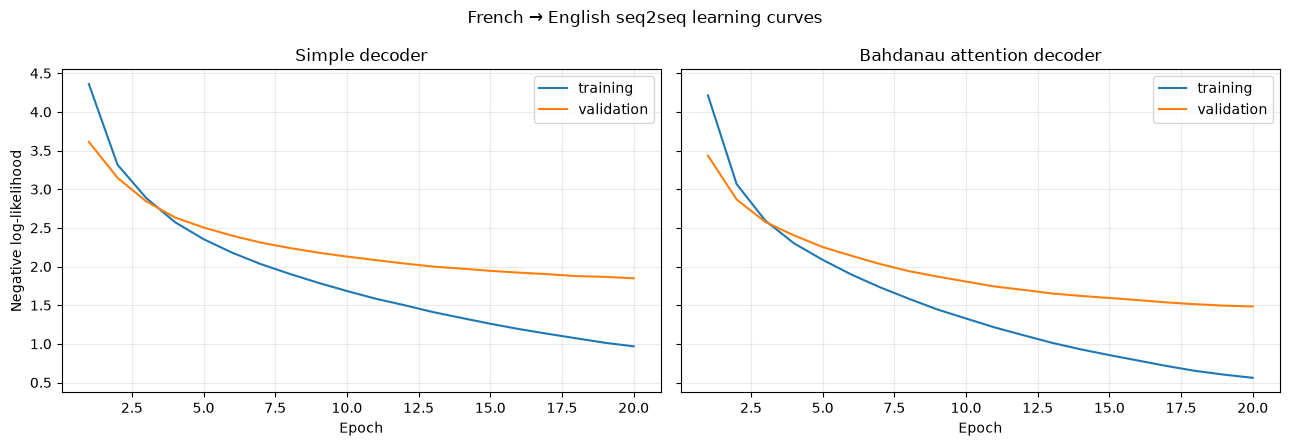

Final validation loss — baseline: 1.8480, attention: 1.4835


In [15]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for axis, title, history in [
    (axes[0], 'Simple decoder', baseline_history),
    (axes[1], 'Bahdanau attention decoder', attention_history),
]:
    axis.plot(epochs, history['train'], label='training')
    axis.plot(epochs, history['validation'], label='validation')
    axis.set_title(title)
    axis.set_xlabel('Epoch')
    axis.grid(alpha=0.25)
    axis.legend()

axes[0].set_ylabel('Negative log-likelihood')
fig.suptitle('French → English seq2seq learning curves')
fig.tight_layout()
plt.show()

print(
    f'Final validation loss — baseline: {baseline_history["validation"][-1]:.4f}, '
    f'attention: {attention_history["validation"][-1]:.4f}'
)

## Evaluate without teacher forcing

Now the decoder must live with its own decisions: its predicted word becomes the next input. The examples below come from the held-out split, so neither model received gradient updates from them. This is still a small, heavily filtered tutorial dataset—not a general French translator.

In [16]:
def evaluate(encoder, decoder, sentence):
    normalized_sentence = normalizeString(sentence)
    unknown_words = [
        word
        for word in normalized_sentence.split(' ')
        if word not in input_lang.word2index
    ]
    if unknown_words:
        raise ValueError(f'Unknown input words: {unknown_words}')

    input_length = len(normalized_sentence.split(' ')) + 1
    input_tensor = tensorFromSentence(input_lang, normalized_sentence)
    encoder.eval()
    decoder.eval()

    with torch.inference_mode():
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, decoder_attention = decoder(
            encoder_outputs, encoder_hidden
        )
        decoded_ids = decoder_outputs.argmax(dim=-1)[0]

    decoded_words = []
    for token_id in decoded_ids.tolist():
        if token_id == EOS_token:
            decoded_words.append('<EOS>')
            break
        decoded_words.append(output_lang.index2word[token_id])

    if decoder_attention is not None:
        decoder_attention = decoder_attention[
            0, :len(decoded_words), :input_length
        ].cpu()

    return normalized_sentence, decoded_words, decoder_attention


def compare_translations(example_pairs):
    for source, target in example_pairs:
        _, baseline_words, _ = evaluate(
            baseline_encoder, baseline_decoder, source
        )
        _, attention_words, _ = evaluate(
            attention_encoder, attention_decoder, source
        )
        print(f'> {source}')
        print(f'= {target}')
        print(f'baseline:  {" ".join(baseline_words)}')
        print(f'attention: {" ".join(attention_words)}')
        print()


example_rng = random.Random(SEED)
held_out_examples = example_rng.sample(validation_pairs, 8)
compare_translations(held_out_examples)

> vous etes tellement previsible !
= you re so predictable
baseline:  you re so sweet <EOS>
attention: you re so bossy <EOS>

> elle est plus jeune que lui
= she s younger than him
baseline:  she s as beautiful as her mother <EOS>
attention: she s much heavier than him <EOS>

> elles sont toutes mauvaises
= they re all bad
baseline:  they re all mine <EOS>
attention: they re all bad <EOS>

> je suis presse aujourd hui
= i m in a hurry today
baseline:  i m ready for <EOS>
attention: i am in favor of a lawyer <EOS>



> je suis consciente des risques
= i m aware of the risks
baseline:  i m in trouble now <EOS>
attention: i m aware of the facts <EOS>

> vous etes toutes heureuses
= you re all happy
baseline:  you re all my friends <EOS>
attention: you re all happy <EOS>

> je suis finlandais mais je parle aussi le suedois
= i am finnish but i speak also swedish
baseline:  i m willing to go to your complaints <EOS>
attention: i m finnish but i can persuade out of coffee

> vous etes precis
= you re precise
baseline:  you re forgiven <EOS>
attention: you re resilient <EOS>



## Visualize where attention looks

Rows are generated English words and columns are French input words. A brighter square means a larger attention weight. Natural translations do not always align word-for-word, but a learned diagonal-ish path often appears because output words usually progress through the input sentence.

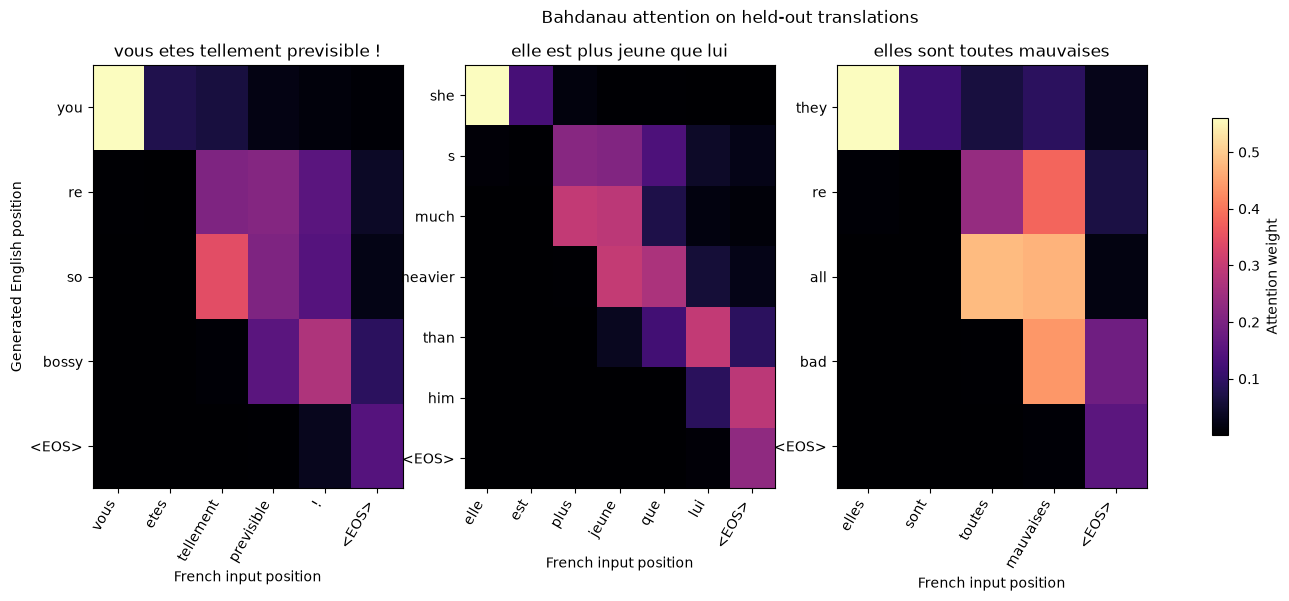

In [17]:
def plot_attention_examples(example_pairs):
    fig, axes = plt.subplots(1, len(example_pairs), figsize=(17, 5.5))
    axes = np.atleast_1d(axes)

    for axis, (source, _) in zip(axes, example_pairs):
        normalized, output_words, attention = evaluate(
            attention_encoder, attention_decoder, source
        )
        image = axis.imshow(attention.numpy(), cmap='magma', aspect='auto')
        input_labels = normalized.split(' ') + ['<EOS>']
        axis.set_xticks(range(len(input_labels)), labels=input_labels, rotation=60, ha='right')
        axis.set_yticks(range(len(output_words)), labels=output_words)
        axis.set_title(normalized)
        axis.set_xlabel('French input position')

    axes[0].set_ylabel('Generated English position')
    fig.colorbar(image, ax=axes.tolist(), shrink=0.75, label='Attention weight')
    fig.suptitle('Bahdanau attention on held-out translations')
    plt.show()


plot_attention_examples(held_out_examples[:3])

## Save the trained models

A notebook output proves training happened, but its in-memory model disappears when the kernel stops. The checkpoint keeps both experiments' learned parameters, vocabularies, configuration, and loss histories. When loading on another machine, pass an appropriate map_location to torch.load.

In [18]:
checkpoint_path = data_dir / 'translation_seq2seq_models.pt'
torch.save(
    {
        'config': {
            'hidden_size': HIDDEN_SIZE,
            'max_length': MAX_LENGTH,
            'epochs': EPOCHS,
            'seed': SEED,
        },
        'input_word2index': input_lang.word2index,
        'input_index2word': input_lang.index2word,
        'output_word2index': output_lang.word2index,
        'output_index2word': output_lang.index2word,
        'baseline_encoder': baseline_encoder.state_dict(),
        'baseline_decoder': baseline_decoder.state_dict(),
        'attention_encoder': attention_encoder.state_dict(),
        'attention_decoder': attention_decoder.state_dict(),
        'baseline_history': baseline_history,
        'attention_history': attention_history,
    },
    checkpoint_path,
)
print(f'Saved checkpoint: {checkpoint_path}')
print(f'Checkpoint size: {checkpoint_path.stat().st_size / 1_000_000:.1f} MB')

Saved checkpoint: /Users/rad/dev/minor/ml/llmsfs/torch/data/translation_seq2seq_models.pt
Checkpoint size: 13.0 MB


## What happened in this run

- The simple decoder ended at **0.9678 training loss / 1.8480 validation loss**.
- The attention decoder ended at **0.5607 training loss / 1.4835 validation loss**. Its held-out loss is about **20% lower** than the baseline's.
- Attention exactly produced examples such as “they're all bad” and “you're all happy,” where the baseline missed the final content word.
- Neither model is a production translator. Both training curves finish well below their validation curves, so they are fitting the training set more closely than unseen examples. The longer Finnish/Swedish sentence also shows how errors compound when the decoder feeds predictions back into itself.

The central lesson is not merely that attention lowers the loss. It changes the information bottleneck: the baseline must compress the entire French sentence into one final hidden state, while the attention decoder can revisit all encoder states for every generated English word.